# ERROR DECOMPOSITION ANALYSIS FOR UTCI

### Calculate error from RMSE 

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [130]:
def var_joint(std_A, std_B, rho):
    if rho == 0:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B
        return var_A_B
    elif rho == 1:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B + 2*np.sqrt(var_A * var_B)
        return var_A_B
    elif rho == -1:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B - 2*np.sqrt(var_A * var_B)
        return var_A_B

In [131]:
# Parameters
std_A = 1.04
std_B_values = np.linspace(0, 3, 10)
rho_values = [0, 1, -1]

In [132]:
df = pd.DataFrame({
    "std_B": std_B_values,
    "rho_1": [var_joint(std_A, b, 1) for b in std_B_values],
    "rho_0": [var_joint(std_A, b, 0) for b in std_B_values],
    "rho_minus_1": [var_joint(std_A, b, -1) for b in std_B_values],

    "per_diff_rho_1": [(var_joint(std_A, b, 1) - 1.04)/1.04 *100 for b in std_B_values],
    "per_diff_rho_0": [(var_joint(std_A, b, 0) - 1.04)/1.04 *100 for b in std_B_values],
    "per_diff_rho_minus_1": [(var_joint(std_A, b, -1) - 1.04)/1.04 *100 for b in std_B_values],

    "per_diff_total_rho_1": [(var_joint(std_A, b, 1) - 1.04)/(var_joint(std_A, b, 1)) *100 for b in std_B_values],
    "per_diff_total_rho_0": [(var_joint(std_A, b, 0) - 1.04)/(var_joint(std_A, b, 0)) *100 for b in std_B_values],
    "per_diff_total_rho_minus_1": [(var_joint(std_A, b, -1) - 1.04)/(var_joint(std_A, b, -1)) *100 for b in std_B_values],

})

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_83384\3511131877.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


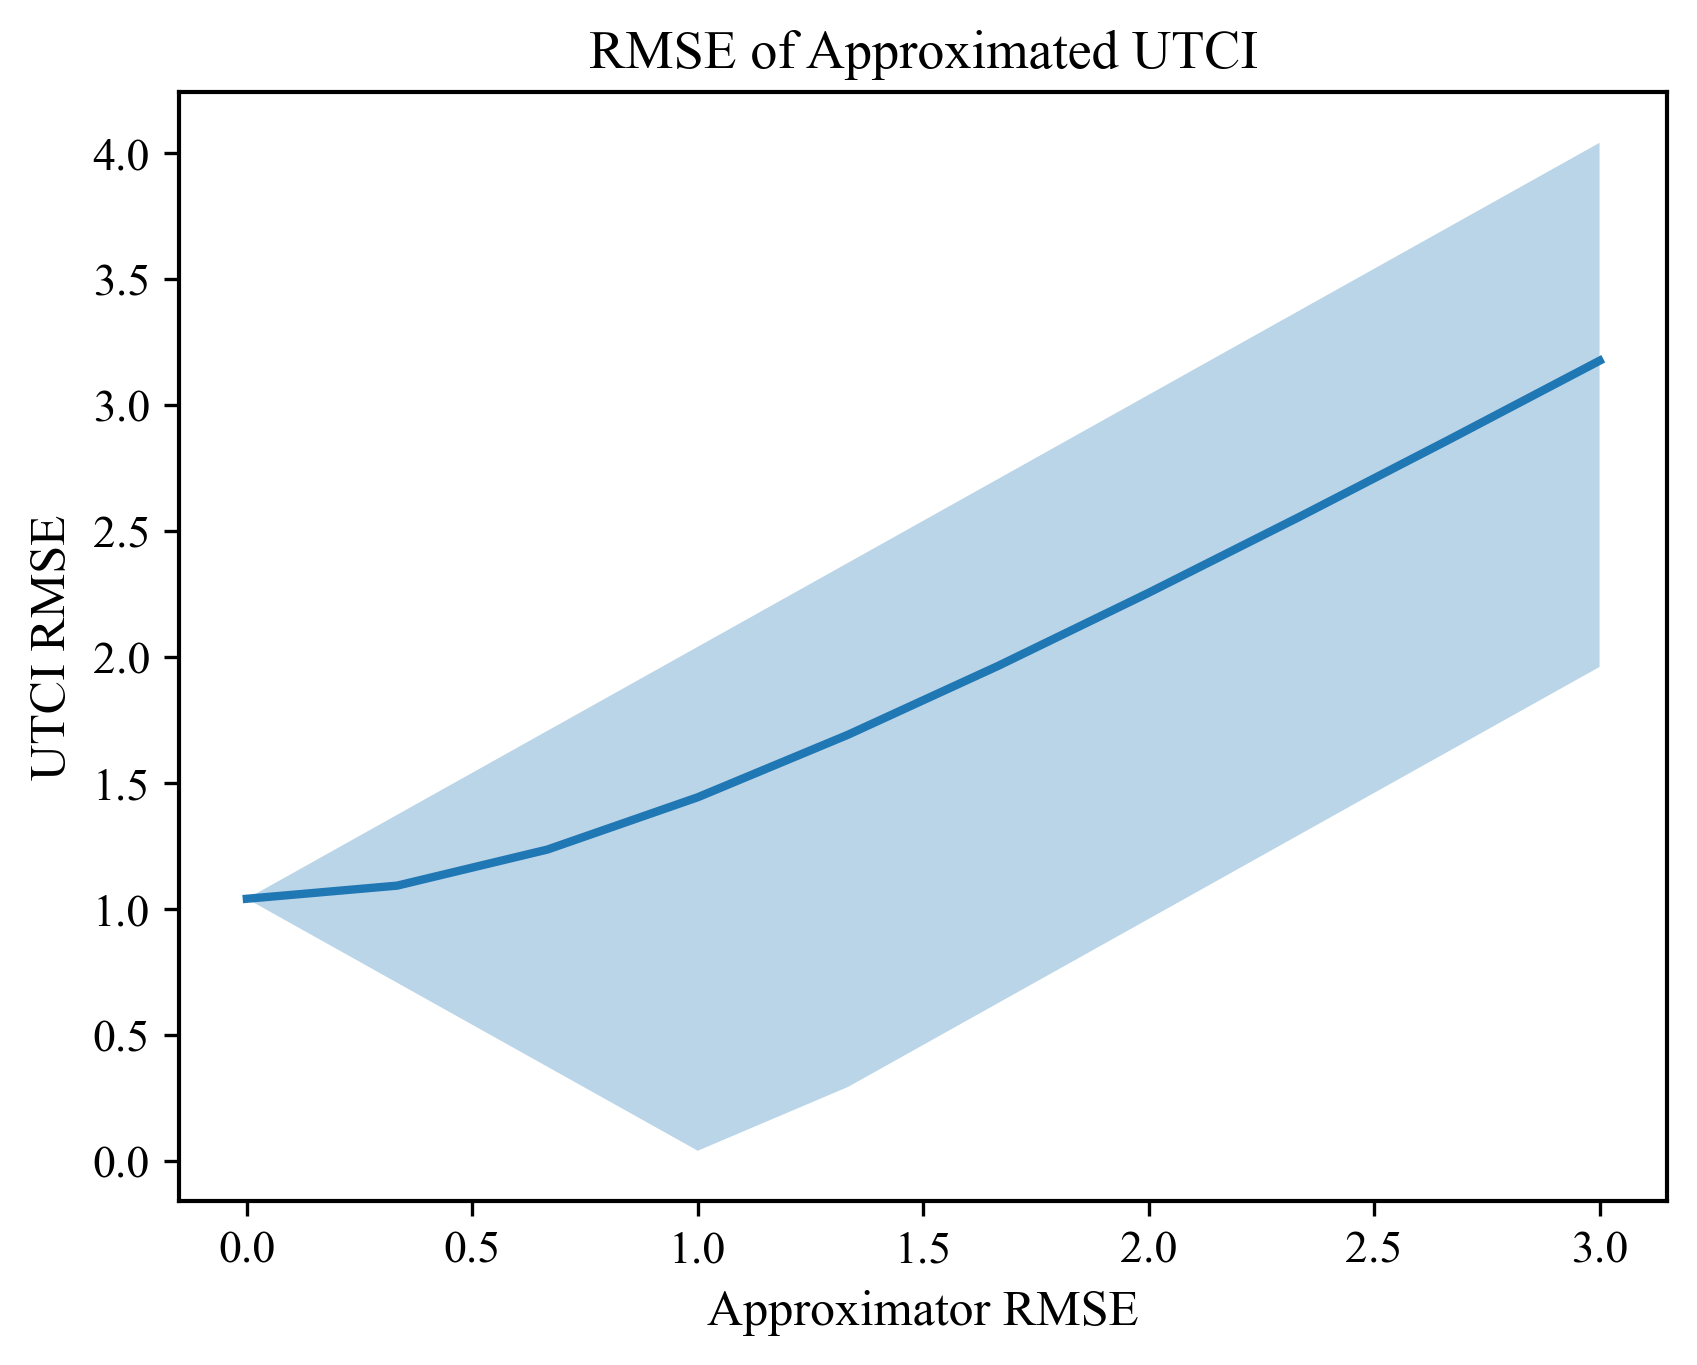

In [133]:
# Plot
plt.figure()


# Uncertainty cloud (between rho=-1 and rho=1)
plt.fill_between(std_B_values, np.sqrt(df["rho_minus_1"]), np.sqrt(df["rho_1"]), alpha=0.3)
plt.plot(std_B_values, np.sqrt(df["rho_0"]), linewidth=2)

plt.xlabel("Approximator RMSE")
plt.ylabel("UTCI RMSE")
plt.title("RMSE of Approximated UTCI")
plt.legend()
plt.show()

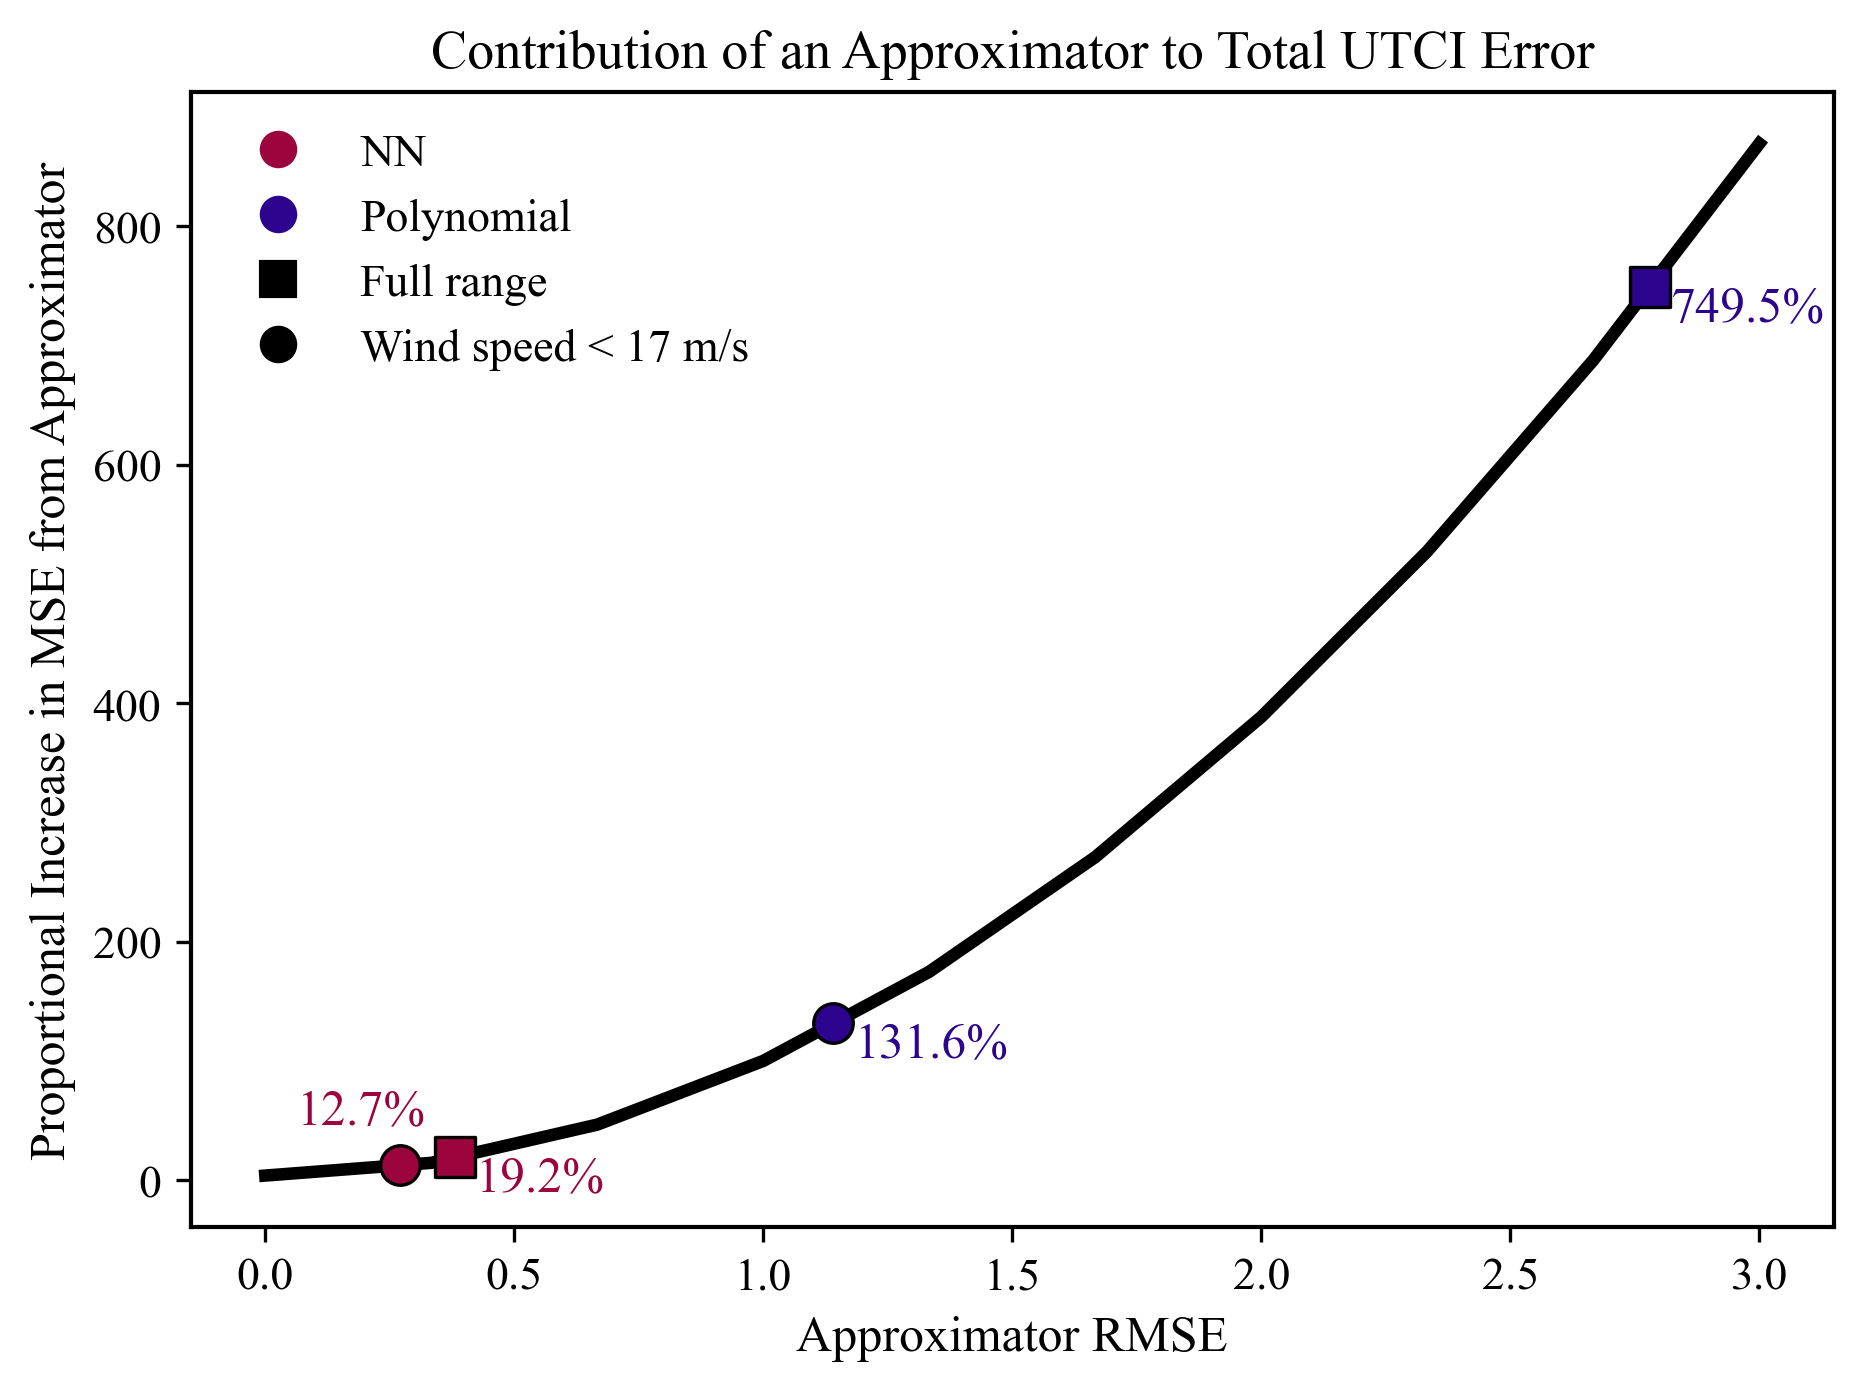

In [134]:

plt.figure()

# Main curve (example: polynomial full range)
plt.plot(std_B_values,
         df["per_diff_rho_0"],
         linewidth=3,
         color='black')

# --- Reference x values ---
x1, x2, x3, x4 = 1.14, 2.78, 0.38, 0.27

y_values = df["per_diff_rho_0"].values
y1 = np.interp(x1, std_B_values, y_values)
y2 = np.interp(x2, std_B_values, y_values)
y3 = np.interp(x3, std_B_values, y_values)
y4 = np.interp(x4, std_B_values, y_values)

# ---------------------------------------------------
# Example assignment of model + regime to each point
# (Adjust according to your actual mapping)
# ---------------------------------------------------
points = [
    # (x, y, color, marker)
    (x1, y1, '#2C048E', 'o'),   # Poly, full range
    (x2, y2, '#2C048E', 's'),   # Poly, wind <17
    (x3, y3, '#9B043D', 's'),  # NN, full range
    (x4, y4, '#9B043D', 'o')   # NN, wind <17
]

# Plot points
for x, y, color, marker in points:
    plt.scatter(x,
                y,
                color=color,
                marker=marker,
                s=90,
                edgecolor='k',
                linewidth=0.8,
                zorder=6)




# Add annotations near each point (tweak xytext offsets as needed)
plt.annotate(f"{y1:.1f}%", (x1, y1), xytext=(5, -8), textcoords="offset points", color='#2C048E')
plt.annotate(f"{y2:.1f}%", (x2, y2), xytext=(5, -8), textcoords="offset points", color='#2C048E')
plt.annotate(f"{y3:.1f}%", (x3, y3), xytext=(5, -8), textcoords="offset points", color='#9B043D')
plt.annotate(f"{y4:.1f}%", (x4, y4), xytext=(-25, 10), textcoords="offset points", color='#9B043D')


legend_elements = [

    # Color legend (Model type)
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#9B043D', markersize=10,
           label='NN'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#2C048E', markersize=10,
           label='Polynomial'),


    # Marker legend (Wind regime)
    Line2D([0], [0], marker='s', color='black',
           linestyle='none', markersize=8,
           label='Full range'),

    Line2D([0], [0], marker='o', color='black',
           linestyle='none', markersize=8,
           label='Wind speed < 17 m/s'),
]

plt.legend(handles=legend_elements,
           frameon=False)

plt.xlabel("Approximator RMSE")
plt.ylabel("Proportional Increase in MSE from Approximator")
plt.title("Contribution of an Approximator to Total UTCI Error")
plt.tight_layout()
plt.show()


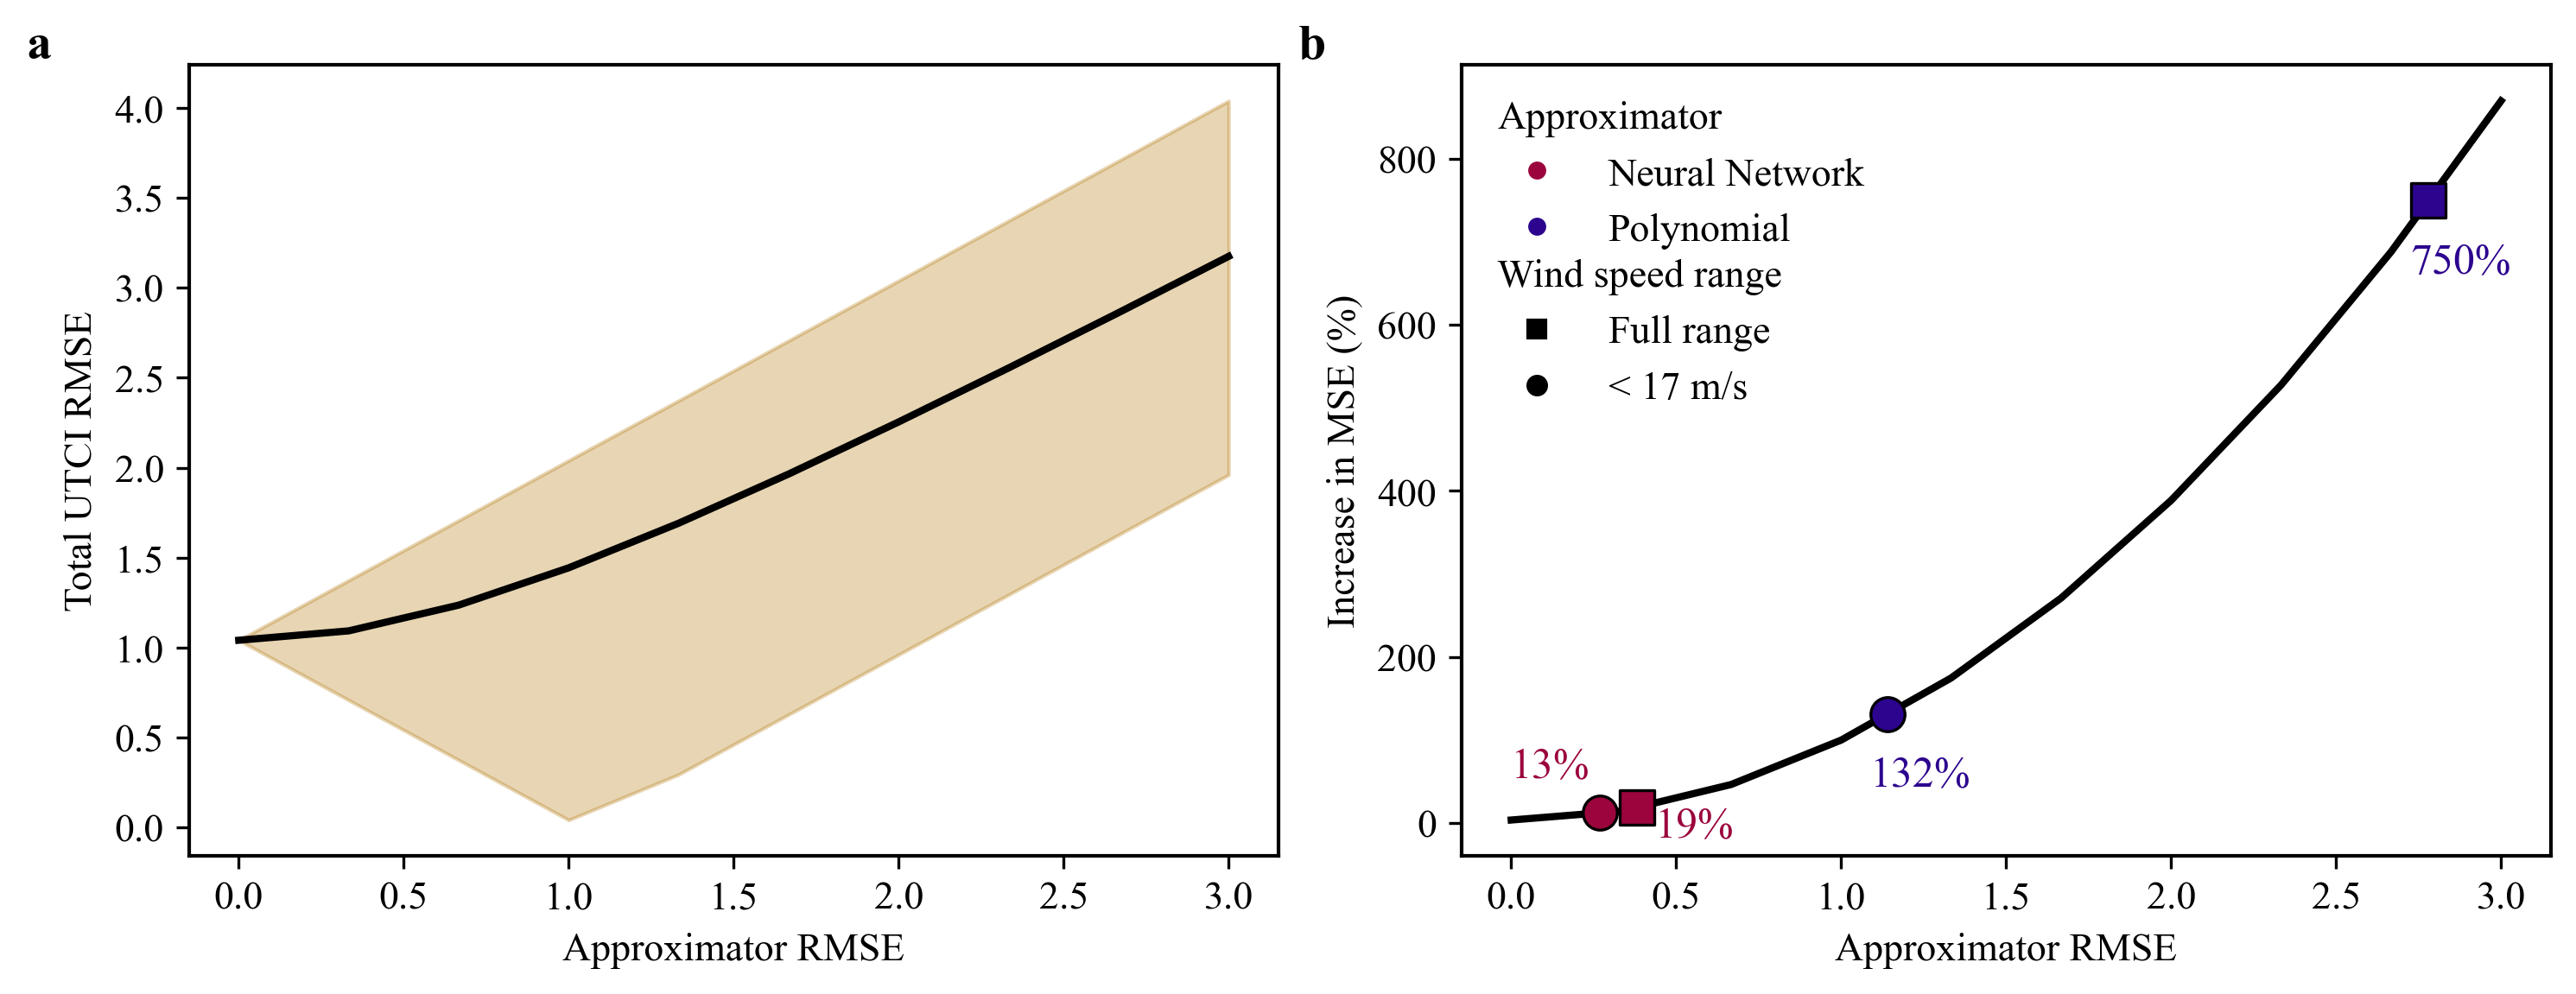

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------
# Publication-quality rc settings
# ---------------------------
plt.rcParams.update({
    'figure.dpi': 300,                    # screen DPI (saving overrides with fig.savefig)
    'savefig.dpi': 600,                   # high-res saves
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,                      # base font size (controls many defaults)
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ---------------------------


# Create two panels side-by-side
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ---------------------------
# Panel A: RMSE of Approximated UTCI (uncertainty cloud + central curve)
# ---------------------------
ax = axs[0]

# defensive: ensure non-negative inside sqrt
lower = np.sqrt(np.maximum(0, df["rho_minus_1"].values))
upper = np.sqrt(np.maximum(0, df["rho_1"].values))
center = np.sqrt(np.maximum(0, df["rho_0"].values))

ax.fill_between(std_B_values, lower, upper, alpha=0.3, label=r'Uncertainty (ρ ∈ [-1,1])', color='#B17405')
ax.plot(std_B_values, center, linewidth=2, label=r'ρ = 0', color='black')

ax.set_xlabel("Approximator RMSE", fontsize=11)
ax.set_ylabel("Total UTCI RMSE", fontsize=11)


# ax.legend(
#     handles=legend_handles,
#     loc='upper right',   # or 'upper left'
#     frameon=False,
#     fontsize=11
# )

# ---------------------------
# Panel B: Contribution of Approximator to Total UTCI Error
# ---------------------------
ax = axs[1]

# main curve
ax.plot(std_B_values, df["per_diff_rho_0"], linewidth=2, color='black', label=None)
ax.set_xlabel("Approximator RMSE", fontsize=11)
ax.set_ylabel("Increase in MSE (%)", fontsize=11)

# Reference x values and their interpolated y positions
x1, x2, x3, x4 = 1.14, 2.78, 0.38, 0.27
y_values = df["per_diff_rho_0"].values
y1 = np.interp(x1, std_B_values, y_values)
y2 = np.interp(x2, std_B_values, y_values)
y3 = np.interp(x3, std_B_values, y_values)
y4 = np.interp(x4, std_B_values, y_values)

# Points to plot: (x, y, color, marker)
points = [
    (x1, y1, '#2C048E', 'o'),   # Poly, full range
    (x2, y2, '#2C048E', 's'),   # Poly, wind <17
    (x3, y3, '#9B043D', 's'),   # NN, full range
    (x4, y4, '#9B043D', 'o')    # NN, wind <17
]

# plot the points
for x, y, color, marker in points:
    # using edgecolor='k' for visibility; for unfilled marker use facecolors='none'
    ax.scatter(x, y, color=color, marker=marker, s=90,
               edgecolor='k', linewidth=0.8, zorder=6)

# annotations (tweak offsets if overlap)
ax.annotate(f"{y1:.0f}%", (x1, y1), xytext=(-5, -20), textcoords="offset points", color='#2C048E')
ax.annotate(f"{y2:.0f}%", (x2, y2), xytext=(-5, -20), textcoords="offset points", color='#2C048E')
ax.annotate(f"{y3:.0f}%", (x3, y3), xytext=(5, -8), textcoords="offset points", color='#9B043D')
ax.annotate(f"{y4:.0f}%", (x4, y4), xytext=(-25, 10), textcoords="offset points", color='#9B043D')

#Legend handles
approximator_handles = [ Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#9B043D', markeredgecolor='none', markersize=5, label='Neural Network'), Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#2C048E', markeredgecolor='none', markersize=5, label='Polynomial'), ]
input_handles = [ Line2D([0], [0], marker='s', linestyle='None', color='black', markersize=5, label='Full range'), Line2D([0], [0], marker='o', linestyle='None', color='black', markersize=5, label='< 17 m/s'), ]
# ---- Approximator legend (top) ----
leg1 = ax.legend(
    handles=approximator_handles,
    title='Approximator',
    loc='upper left',
    bbox_to_anchor=(0.0, 1.0),   # anchor to top-left of axes
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    alignment='left'
)

ax.add_artist(leg1)


# ---- Input range legend (directly underneath) ----
leg2 = ax.legend(
    handles=input_handles,
    title='Wind speed range',
    loc='upper left',
    bbox_to_anchor=(0.0, 0.80),   # move downward — adjust slightly if needed
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    alignment='left'
)

# ---------------------------
# Panel labeling (a, b)
# ---------------------------
panel_labels = ['a', 'b']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')


plt.tight_layout()


plt.savefig("supplementary/combined_rmse_contribution.png", dpi=360, bbox_inches='tight', transparent=False)

plt.show()
